### 安装vanna

In [6]:
pip install vanna[chromadb,mysql] dashscope

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install "posthog>=2.4.0,<6.0.0"

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [28]:
pip install nbformat

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
from vanna.base import VannaBase
from vanna.chromadb import ChromaDB_VectorStore
from dashscope import Generation  #用于调Qwen

### 自定义LLM

https://vanna.ai/docs/mysql-other-llm-chromadb/

In [3]:
import random

DERUG_INFO=None
#将大模型的输入输出记录在DERUG_INFO里

class QwenLLM(VannaBase):
    def __init__(self, config=None):
        self.model=config['model']
        self.api_key=config['api_key']

    def system_message(self, message: str):
        return {"role": "system", "content": message}

    def user_message(self, message: str):
        return {"role": "user", "content": message}

    def assistant_message(self, message: str):
        return {"role": "assistant", "content": message}
        
    def submit_prompt(self, prompt, **kwargs):
        resp=Generation.call(
            model=self.model,
            messages=prompt,
            seed=random.randint(1,10000),
            result_format='message',
            api_key=self.api_key)
        answer=resp.output.choices[0].message.content
        global DEBUG_INFO
        DEBUG_INFO=(prompt,answer)
        return answer

##组装prompt

### Vanna客户端

In [4]:
class MyVanna(ChromaDB_VectorStore, QwenLLM):
    def __init__(self, config=None):
        ChromaDB_VectorStore.__init__(self, config=config)
        QwenLLM.__init__(self, config=config)

vn = MyVanna({'api_key':'sk-caf01c1467e4469cb3c89cdd6def7472','model':'qwen-max'})

### MySQL客户端

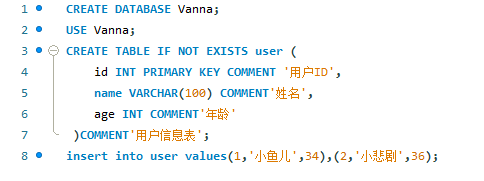

In [5]:
vn.connect_to_mysql(host='localhost', dbname='Vanna', user='root', password='123456', port=3306)

In [6]:
DDL = '''CREATE TABLE IF NOT EXISTS user (
    	id INT PRIMARY KEY COMMENT '用户ID', 
    	name VARCHAR(100) COMMENT'姓名', 
    	age INT COMMENT'年龄'
     )COMMENT'用户信息表';
'''

In [7]:
#存储DDL到向量库
vn.train(ddl=DDL)
#多张表要train多次

Adding ddl: CREATE TABLE IF NOT EXISTS user (
    	id INT PRIMARY KEY COMMENT '用户ID', 
    	name VARCHAR(100) COMMENT'姓名', 
    	age INT COMMENT'年龄'
     )COMMENT'用户信息表';



'90a10326-8aec-5ff1-8fbb-e8c9c368b6f0-ddl'

In [8]:
#存储document到向量库
vn.train(documentation='“福报”是指age>=35岁，也就是可以向社会输送的人才')

Adding documentation....


'0a21243c-8a7a-53bd-adf9-16d7d62be10b-doc'

In [9]:
#存储SQL到向量库
'''
 1. 通过LLM根据SQL构造question（逻辑描述，未完整实现代码）
 2. 按question-SQL的JSON入库（逻辑描述，示例结构）
 {
     "question": question,
     "sql": sql,
 }
 '''
vn.train(sql='select name from user where age between 10 and 20')

Question generated with sql: What are the names of users whose age is between 10 and 20? 
Adding SQL...


'9ccf7bcd-5091-5b97-bf72-af9d41e526a5-sql'

In [10]:
#vanna用上面插入的sql干了什么（用sql语句反推问题，但是是英文）
Q,A=DEBUG_INFO
print('PROMPT:',Q[0]['content'])
print('ANSWER:',A)

PROMPT: The user will give you SQL and you will try to guess what the business question this query is answering. Return just the question without any additional explanation. Do not reference the table name in the question.
ANSWER: What are the names of users whose age is between 10 and 20?


In [11]:
#存储question-SQL到向量库
'''
 按question-SQL的JSON入库
             {
                 "question":question,
                 "sql":sql,
             }
'''
vn.train(question='小鱼儿的年龄',sql='select age from user where name = "小鱼儿"')

'f7ca0c10-3da0-5820-ad17-11107cade7a0-sql'

In [12]:
#检查所有入库知识
vn.get_training_data()

,id,question,content,training_data_type
0,9ccf7bcd-5091-5b97-bf72-af9d41e526a5-sql,What are the names of users whose age is betwe...,select name from user where age between 10 and 20,sql
1,f7ca0c10-3da0-5820-ad17-11107cade7a0-sql,小鱼儿的年龄,"select age from user where name = ""小鱼儿""",sql
0,90a10326-8aec-5ff1-8fbb-e8c9c368b6f0-ddl,None,CREATE TABLE IF NOT EXISTS user (\n \tid IN...,ddl
0,0a21243c-8a7a-53bd-adf9-16d7d62be10b-doc,None,“福报”是指age>=35岁，也就是可以向社会输送的人才,documentation


### 开始查询

In [13]:
#基本使用

#1.只要sql语句
result = vn.generate_sql('用户的平均年龄')
print('SQL:', result)

Q,A=DEBUG_INFO
print('PROMPT:',Q[0]['content'])
print('ANSWER:',A)

Number of requested results 10 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1


SQL Prompt: [{'role': 'system', 'content': "You are a SQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE IF NOT EXISTS user (\n    \tid INT PRIMARY KEY COMMENT '用户ID', \n    \tname VARCHAR(100) COMMENT'姓名', \n    \tage INT COMMENT'年龄'\n     )COMMENT'用户信息表';\n\n\n\n===Additional Context \n\n“福报”是指age>=35岁，也就是可以向社会输送的人才\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the provided context is almost sufficient but requires knowledge of a specific string in a particular column, please generate an intermediate SQL query to find the distinct strings in that column. Prepend the query with a comment saying intermediate_sql \n3. If the provided context is insufficient, please explain why it can't be generated. \n4. Please use the

Number of requested results 10 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1


SQL Prompt: [{'role': 'system', 'content': "You are a SQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE IF NOT EXISTS user (\n    \tid INT PRIMARY KEY COMMENT '用户ID', \n    \tname VARCHAR(100) COMMENT'姓名', \n    \tage INT COMMENT'年龄'\n     )COMMENT'用户信息表';\n\n\n\n===Additional Context \n\n“福报”是指age>=35岁，也就是可以向社会输送的人才\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the provided context is almost sufficient but requires knowledge of a specific string in a particular column, please generate an intermediate SQL query to find the distinct strings in that column. Prepend the query with a comment saying intermediate_sql \n3. If the provided context is insufficient, please explain why it can't be generated. \n4. Please use the

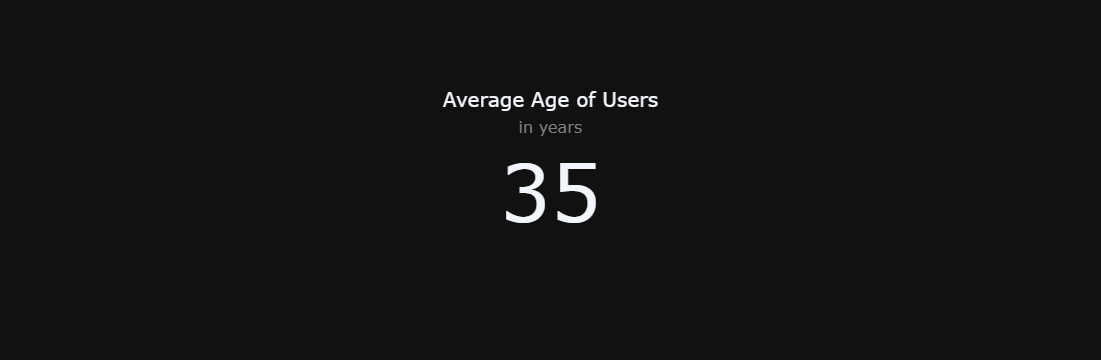

('select avg(age) from user',
   avg(age)
 0  35.0000,
 Figure({
     'data': [{'domain': {'x': [0, 1], 'y': [0, 1]},
               'mode': 'number',
               'title': {'text': "Average Age of Users<BR><span style='font-size:0.8em;color:gray'>in years</span>"},
               'type': 'indicator',
               'value': 35.0}],
     'layout': {'template': '...'}
 }))

In [14]:
#2.自然语言问答（画图功能很鸡肋）

vn.ask('用户的平均年龄')

In [15]:
result = vn.generate_sql('打算给一批员工送福报，把他们的名字过滤出来')

WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 3, updating n_results = 3
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1


SQL Prompt: [{'role': 'system', 'content': "You are a SQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE IF NOT EXISTS user (\n    \tid INT PRIMARY KEY COMMENT '用户ID', \n    \tname VARCHAR(100) COMMENT'姓名', \n    \tage INT COMMENT'年龄'\n     )COMMENT'用户信息表';\n\n\n\n===Additional Context \n\n“福报”是指age>=35岁，也就是可以向社会输送的人才\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the provided context is almost sufficient but requires knowledge of a specific string in a particular column, please generate an intermediate SQL query to find the distinct strings in that column. Prepend the query with a comment saying intermediate_sql \n3. If the provided context is insufficient, please explain why it can't be generated. \n4. Please use the

WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 3, updating n_results = 3
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1


SQL Prompt: [{'role': 'system', 'content': "You are a SQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE IF NOT EXISTS user (\n    \tid INT PRIMARY KEY COMMENT '用户ID', \n    \tname VARCHAR(100) COMMENT'姓名', \n    \tage INT COMMENT'年龄'\n     )COMMENT'用户信息表';\n\n\n\n===Additional Context \n\n“福报”是指age>=35岁，也就是可以向社会输送的人才\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the provided context is almost sufficient but requires knowledge of a specific string in a particular column, please generate an intermediate SQL query to find the distinct strings in that column. Prepend the query with a comment saying intermediate_sql \n3. If the provided context is insufficient, please explain why it can't be generated. \n4. Please use the

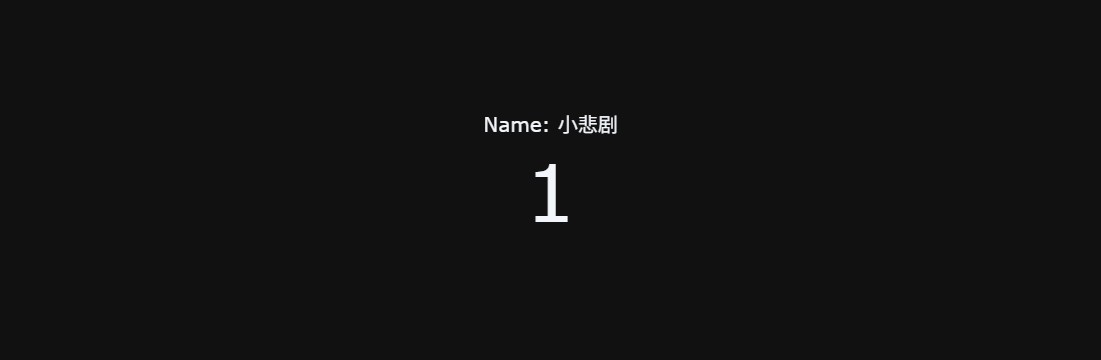

('select name from user where age >= 35',
   name
 0  小悲剧,
 Figure({
     'data': [{'mode': 'number', 'title': {'text': 'Name: 小悲剧'}, 'type': 'indicator', 'value': 1}],
     'layout': {'template': '...'}
 }))

In [16]:
vn.ask('打算给一批员工送福报，把他们的名字过滤出来')

In [17]:
result = vn.generate_sql('统计一下各年龄段的用户数量,年龄段是按0-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80...左闭右开区间')

WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 4, updating n_results = 4
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1


SQL Prompt: [{'role': 'system', 'content': "You are a SQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE IF NOT EXISTS user (\n    \tid INT PRIMARY KEY COMMENT '用户ID', \n    \tname VARCHAR(100) COMMENT'姓名', \n    \tage INT COMMENT'年龄'\n     )COMMENT'用户信息表';\n\n\n\n===Additional Context \n\n“福报”是指age>=35岁，也就是可以向社会输送的人才\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the provided context is almost sufficient but requires knowledge of a specific string in a particular column, please generate an intermediate SQL query to find the distinct strings in that column. Prepend the query with a comment saying intermediate_sql \n3. If the provided context is insufficient, please explain why it can't be generated. \n4. Please use the

In [18]:
# 知识沉淀后可以直接提问
vn.train(documentation='用户年龄段划分逻辑:0-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80...左闭右开区间')
vn.generate_sql('统计一下各年龄段的用户数量')

WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 4, updating n_results = 4
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 2, updating n_results = 2


Adding documentation....
SQL Prompt: [{'role': 'system', 'content': "You are a SQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE IF NOT EXISTS user (\n    \tid INT PRIMARY KEY COMMENT '用户ID', \n    \tname VARCHAR(100) COMMENT'姓名', \n    \tage INT COMMENT'年龄'\n     )COMMENT'用户信息表';\n\n\n\n===Additional Context \n\n用户年龄段划分逻辑:0-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80...左闭右开区间\n\n“福报”是指age>=35岁，也就是可以向社会输送的人才\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the provided context is almost sufficient but requires knowledge of a specific string in a particular column, please generate an intermediate SQL query to find the distinct strings in that column. Prepend the query with a comment saying intermediate_sql \n3. If the p

"SELECT \n  CASE\n    WHEN age < 10 THEN '0-10'\n    WHEN age < 20 THEN '10-20'\n    WHEN age < 30 THEN '20-30'\n    WHEN age < 40 THEN '30-40'\n    WHEN age < 50 THEN '40-50'\n    WHEN age < 60 THEN '50-60'\n    WHEN age < 70 THEN '60-70'\n    WHEN age < 80 THEN '70-80'\n    ELSE '80+'\n  END AS age_group,\n  COUNT(*) AS user_count\nFROM user\nGROUP BY age_group;"

WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 4, updating n_results = 4
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 1, updating n_results = 1
WARNING	chromadb.segment.impl.vector.local_persistent_hnsw:local_persistent_hnsw.py:query_vectors()- Number of requested results 10 is greater than number of elements in index 2, updating n_results = 2


SQL Prompt: [{'role': 'system', 'content': "You are a SQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE IF NOT EXISTS user (\n    \tid INT PRIMARY KEY COMMENT '用户ID', \n    \tname VARCHAR(100) COMMENT'姓名', \n    \tage INT COMMENT'年龄'\n     )COMMENT'用户信息表';\n\n\n\n===Additional Context \n\n用户年龄段划分逻辑:0-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80...左闭右开区间\n\n“福报”是指age>=35岁，也就是可以向社会输送的人才\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the provided context is almost sufficient but requires knowledge of a specific string in a particular column, please generate an intermediate SQL query to find the distinct strings in that column. Prepend the query with a comment saying intermediate_sql \n3. If the provided context is insuff

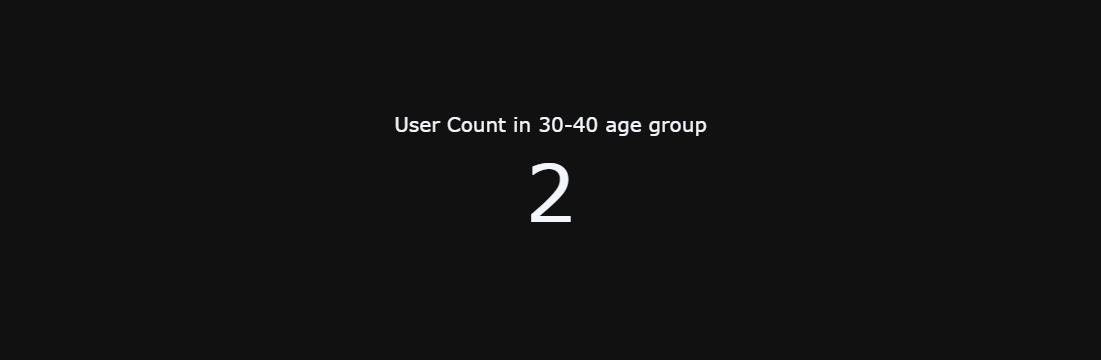

("SELECT \n    CASE \n        WHEN age BETWEEN 0 AND 10 THEN '0-10'\n        WHEN age BETWEEN 10 AND 20 THEN '10-20'\n        WHEN age BETWEEN 20 AND 30 THEN '20-30'\n        WHEN age BETWEEN 30 AND 40 THEN '30-40'\n        WHEN age BETWEEN 40 AND 50 THEN '40-50'\n        WHEN age BETWEEN 50 AND 60 THEN '50-60'\n        WHEN age BETWEEN 60 AND 70 THEN '60-70'\n        WHEN age BETWEEN 70 AND 80 THEN '70-80'\n        ELSE '80+'\n    END AS age_group,\n    COUNT(*) AS user_count\nFROM user\nGROUP BY age_group;",
   age_group  user_count
 0     30-40           2,
 Figure({
     'data': [{'mode': 'number',
               'title': {'text': 'User Count in 30-40 age group'},
               'type': 'indicator',
               'value': np.int64(2)}],
     'layout': {'template': '...'}
 }))

In [19]:
vn.ask('统计一下各年龄段的用户数量')